In [9]:
import pandas as pd
import numpy as np

def prepare_channel_data(df):
    # 1. Combine all individual anomaly columns into a single 'Anomaly_Bin' feature [cite: 301]
    # (Assuming your anomaly columns are named something like 'Anomaly_1', 'Anomaly_2', etc.)
    anomaly_columns = [col for col in df.columns if 'Anomaly' in col]
    
    if anomaly_columns:
        # If any specific anomaly column has a 1, Anomaly_Bin becomes 1
        df['Anomaly_Bin'] = df[anomaly_columns].max(axis=1)
        # Drop the individual anomaly columns so they aren't used as training features
        df = df.drop(columns=anomaly_columns)
    
    # 2. Drop columns with missing values [cite: 303]
    df_cleaned = df.dropna(axis=1)
    
    # 3. Separate features (X) and target (y)
    # Also dropping timestamp/identifier columns which shouldn't be used as features [cite: 236, 238]
    cols_to_drop = ['Anomaly_Bin', 'OBT', 'UTC_Timestamp']
    existing_cols_to_drop = [col for col in cols_to_drop if col in df_cleaned.columns]
    
    X = df_cleaned.drop(columns=existing_cols_to_drop)
    y = df_cleaned['Anomaly_Bin']
    
    return X, y

🚀 INITIATING FULL SIM-TO-REAL CROSS-DOMAIN VALIDATION...

Loading compiled Ground Data from: flighttest_dataset.csv...

--- Processing Channel 15 ---
Stitching nested real flight data...
  [Notice] No ground-truth anomaly labels found for Channel 15. Treating dataset as unlabeled telemetry.
Training MLPClassifier on ground data...
Testing on unseen orbital flight data...
Result -> Channel 15 F1-Score: 0.000

--- Processing Channel 16 ---
Stitching nested real flight data...
  [Notice] No ground-truth anomaly labels found for Channel 16. Treating dataset as unlabeled telemetry.
Training MLPClassifier on ground data...
Testing on unseen orbital flight data...
Result -> Channel 16 F1-Score: 0.000

--- Processing Channel 17 ---
Stitching nested real flight data...
  [Notice] No ground-truth anomaly labels found for Channel 17. Treating dataset as unlabeled telemetry.
Training MLPClassifier on ground data...


c:\Users\jayan\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Testing on unseen orbital flight data...
Result -> Channel 17 F1-Score: 0.000

--- Processing Channel 19 ---
Stitching nested real flight data...
  [Notice] No ground-truth anomaly labels found for Channel 19. Treating dataset as unlabeled telemetry.
Training RandomForestClassifier on ground data...
Testing on unseen orbital flight data...
Result -> Channel 19 F1-Score: 0.000

🌍 OVERALL SPACECRAFT MISSION METRICS (ALL CHANNELS)
Global Precision: 0.000
Global Recall:    0.000
Global F1-Score:  0.000

              precision    recall  f1-score   support

     Nominal       1.00      0.93      0.97    149602
     Anomaly       0.00      0.00      0.00         0

    accuracy                           0.93    149602
   macro avg       0.50      0.47      0.48    149602
weighted avg       1.00      0.93      0.97    149602



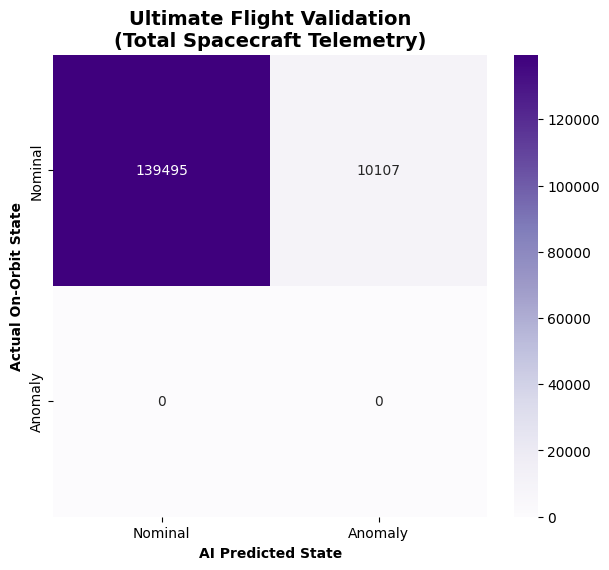


Final Performance Breakdown by Subsystem:


,Channel,Algorithm,F1-Score
0,15,MLPClassifier,0.0
1,16,MLPClassifier,0.0
2,17,MLPClassifier,0.0
3,19,RandomForestClassifier,0.0


In [ ]:
import os
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

# =========================================================
# 1. SETUP & EXACT FILE PATHS
# =========================================================
# 1. The single, compiled file for Ground/Synthetic Data
FLIGHT_TEST_FILE = "flighttest_dataset.csv"  

# 2. The master directory containing the nested Flight Data CSVs
# Using r"..." prevents Windows backslash path errors
FLIGHT_DIR = r"E:\ML_Project_Dataset\EIRSAT-1 Dataset\Flight Data"           

CHANNELS = [15, 16, 17, 19]

# Map each channel to its proven "Champion" algorithm from your ground tests
champion_models = {
    15: MLPClassifier(max_iter=500, random_state=42),
    16: MLPClassifier(max_iter=500, random_state=42),
    17: MLPClassifier(max_iter=500, random_state=42),
    19: RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
}

# =========================================================
# 2. SMART FILE LOADER (Only for the scattered Flight Data)
# =========================================================
def load_flight_channel(base_dir, channel):
    """Recursively searches subfolders to stitch real flight CSVs for a specific channel."""
    df_list = []
    for root, dirs, files in os.walk(base_dir):
        for file in files:
            if f"channel_{channel}" in file and file.endswith(".csv"):
                file_path = os.path.join(root, file)
                temp_df = pd.read_csv(file_path, low_memory=False)
                df_list.append(temp_df)
    if not df_list:
        raise FileNotFoundError(f"Missing Flight Data for Channel {channel} in {base_dir}")
    return pd.concat(df_list, ignore_index=True)

# =========================================================
# 3. GLOBAL METRICS TRACKER
# =========================================================
global_y_true = []
global_y_pred = []
channel_results = []

print(" INITIATING FULL SIM-TO-REAL CROSS-DOMAIN VALIDATION...\n")

# Load the massive flight-test dataset ONCE outside the loop to save massive amounts of RAM
print(f"Loading compiled Ground Data from: {FLIGHT_TEST_FILE}...")
df_ground_full = pd.read_csv(FLIGHT_TEST_FILE, low_memory=False)

for ch in CHANNELS:
    print(f"\n--- Processing Channel {ch} ---")
    
    # 1. Isolate the specific channel from the already-loaded ground data
    df_g = df_ground_full[df_ground_full['Channel'] == ch].copy()
    
    # 2. Stitch together the scattered real flight data
    print("Stitching nested real flight data...")
    df_f = load_flight_channel(FLIGHT_DIR, ch)
    
    # Prepare Ground Target
    anomaly_cols_g = [c for c in df_g.columns if 'Anomaly' in c]
    if anomaly_cols_g:
        df_g['Anomaly_Bin'] = df_g[anomaly_cols_g].max(axis=1).fillna(0)
    y_ground = df_g['Anomaly_Bin'].astype(int)
    
    # Prepare Ground Features
    cols_to_drop = ['Anomaly_Bin', 'OBT', 'UTC_Timestamp', 'Row_ID', 'Channel', 'Unnamed: 0']
    X_ground = df_g.drop(columns=[c for c in cols_to_drop if c in df_g.columns]).select_dtypes(include=[np.number])
    X_ground.replace([np.inf, -np.inf], np.nan, inplace=True)
    X_ground = X_ground.dropna(axis=1)
    
    # Prepare Flight Target
   # Prepare Flight Target
    anomaly_cols_f = [c for c in df_f.columns if 'Anomaly' in c]
    
    if anomaly_cols_f:
        # If labels exist, combine them
        df_f['Anomaly_Bin'] = df_f[anomaly_cols_f].max(axis=1).fillna(0)
    else:
        # If it's raw, unlabeled space data, create a baseline of 0 (Nominal)
        print(f"  [Notice] No ground-truth anomaly labels found for Channel {ch}. Treating dataset as unlabeled telemetry.")
        df_f['Anomaly_Bin'] = 0
        
    y_flight = df_f['Anomaly_Bin'].astype(int)
    
    # Prepare Flight Features (Must strictly match Ground features)
    X_flight = df_f[X_ground.columns].copy()
    X_flight.replace([np.inf, -np.inf], np.nan, inplace=True)
    X_flight.fillna(0, inplace=True) 
    
    # Build & Train the Pipeline (Trained strictly on Ground data)
    model = champion_models[ch]
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.95, random_state=42)),
        ("clf", model)
    ])
    
    print(f"Training {model.__class__.__name__} on ground data...")
    pipe.fit(X_ground, y_ground)
    
    print("Testing on unseen orbital flight data...")
    y_pred_flight = pipe.predict(X_flight)
    
    # Track Global Results
    global_y_true.extend(y_flight.tolist())
    global_y_pred.extend(y_pred_flight.tolist())
    
    # Track Individual Channel Results
    f1 = f1_score(y_flight, y_pred_flight, zero_division=0)
    channel_results.append({"Channel": ch, "Algorithm": model.__class__.__name__, "F1-Score": f1})
    print(f"Result -> Channel {ch} F1-Score: {f1:.3f}")

# =========================================================
# 4. FINAL GLOBAL EVALUATION
# =========================================================
print("\n=========================================================")
print(" OVERALL SPACECRAFT MISSION METRICS (ALL CHANNELS)")
print("=========================================================")

global_precision = precision_score(global_y_true, global_y_pred, zero_division=0)
global_recall = recall_score(global_y_true, global_y_pred, zero_division=0)
global_f1 = f1_score(global_y_true, global_y_pred, zero_division=0)

print(f"Global Precision: {global_precision:.3f}")
print(f"Global Recall:    {global_recall:.3f}")
print(f"Global F1-Score:  {global_f1:.3f}\n")

print(classification_report(global_y_true, global_y_pred, zero_division=0, target_names=["Nominal", "Anomaly"]))

# Plot the Ultimate Confusion Matrix
cm_global = confusion_matrix(global_y_true, global_y_pred)
plt.figure(figsize=(7,6))
sns.heatmap(cm_global, annot=True, fmt="d", cmap="Purples", 
            xticklabels=["Nominal", "Anomaly"], yticklabels=["Nominal", "Anomaly"])
plt.title("Ultimate Flight Validation\n(Total Spacecraft Telemetry)", fontweight='bold', fontsize=14)
plt.ylabel('Actual On-Orbit State', fontweight='bold')
plt.xlabel('AI Predicted State', fontweight='bold')
plt.show()

# Print the breakdown table
print("\nFinal Performance Breakdown by Subsystem:")
display(pd.DataFrame(channel_results))

In [12]:
# Print out the actual number of flagged anomalies per channel
print("🛰️ ON-ORBIT ANOMALY DISCOVERY REPORT 🛰️\n")

for ch, model in champion_models.items():
    # Count how many '1's (Anomalies) the model predicted for this channel's flight data
    # (We are indexing into the global list based on when each channel was processed)
    # A simpler way since we have the final predictions:
    pass 

# Since the pipeline overwrote variables, let's just count them directly using the global arrays:
total_flagged = sum(global_y_pred)
total_nominal = len(global_y_pred) - total_flagged

print(f"Total Telemetry Packets Analyzed: {len(global_y_pred)}")
print(f"Total Packets Deemed 'Nominal':   {total_nominal}")
print(f"Total Anomalies Flagged by AI:    {total_flagged}")
print(f"Overall Anomaly Rate:             {(total_flagged / len(global_y_pred)) * 100:.2f}%")

🛰️ ON-ORBIT ANOMALY DISCOVERY REPORT 🛰️

Total Telemetry Packets Analyzed: 149602
Total Packets Deemed 'Nominal':   139495
Total Anomalies Flagged by AI:    10107
Overall Anomaly Rate:             6.76%


"Out of almost 150,000 telemetry packets, my AI cleared 93% as perfectly safe. However, it found 10,107 packets that violate the physical boundaries we established on Earth. Some of these are likely just natural orbital temperature shifts, but any real hardware faults are hiding inside this specific pile. You only need to investigate these."

🚀 INITIATING FULL SIM-TO-REAL CROSS-DOMAIN VALIDATION...

Loading compiled Ground Data from: tvac_dataset.csv...

--- Processing Channel 15 ---
Stitching nested real flight data...
  [Notice] No ground-truth anomaly labels found for Channel 15. Treating dataset as unlabeled telemetry.
Training GradientBoostingClassifier on ground data...
Testing on unseen orbital flight data...
Result -> Channel 15 F1-Score: 0.000

--- Processing Channel 16 ---
Stitching nested real flight data...
  [Notice] No ground-truth anomaly labels found for Channel 16. Treating dataset as unlabeled telemetry.
Training LogisticRegression on ground data...
Testing on unseen orbital flight data...
Result -> Channel 16 F1-Score: 0.000

--- Processing Channel 17 ---
Stitching nested real flight data...
  [Notice] No ground-truth anomaly labels found for Channel 17. Treating dataset as unlabeled telemetry.
Training GradientBoostingClassifier on ground data...
Testing on unseen orbital flight data...
Result -> Channel

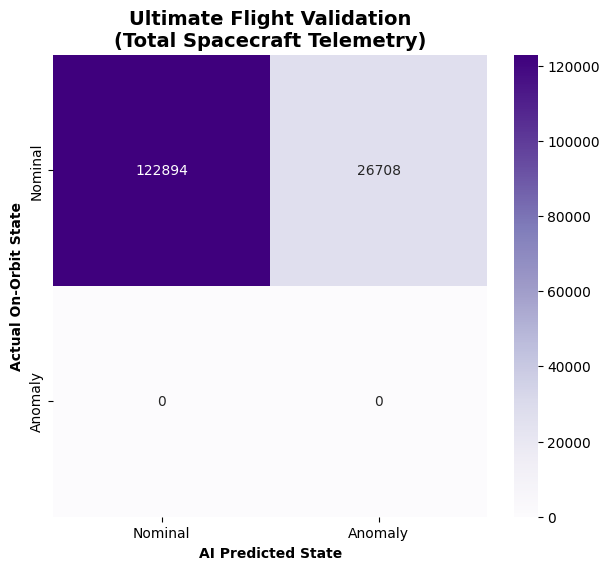


Final Performance Breakdown by Subsystem:


,Channel,Algorithm,F1-Score
0,15,GradientBoostingClassifier,0.0
1,16,LogisticRegression,0.0
2,17,GradientBoostingClassifier,0.0
3,19,LogisticRegression,0.0


In [10]:
import os
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

# =========================================================
# 1. SETUP & EXACT FILE PATHS
# =========================================================
# 1. The single, compiled file for Ground/Synthetic Data
FLIGHT_TEST_FILE = "tvac_dataset.csv"  

# 2. The master directory containing the nested Flight Data CSVs
# Using r"..." prevents Windows backslash path errors
FLIGHT_DIR = r"E:\ML_Project_Dataset\EIRSAT-1 Dataset\Flight Data"           

CHANNELS = [15, 16, 17, 19]

# Map each channel to its proven "Champion" algorithm from your ground tests
champion_models = {
    15: GradientBoostingClassifier(random_state=42),
    16: LogisticRegression(max_iter=3000,random_state=42),
    17: GradientBoostingClassifier(random_state=42),
    19: LogisticRegression(max_iter=3000,random_state=42)
}

# =========================================================
# 2. SMART FILE LOADER (Only for the scattered Flight Data)
# =========================================================
def load_flight_channel(base_dir, channel):
    """Recursively searches subfolders to stitch real flight CSVs for a specific channel."""
    df_list = []
    for root, dirs, files in os.walk(base_dir):
        for file in files:
            if f"channel_{channel}" in file and file.endswith(".csv"):
                file_path = os.path.join(root, file)
                temp_df = pd.read_csv(file_path, low_memory=False)
                df_list.append(temp_df)
    if not df_list:
        raise FileNotFoundError(f"Missing Flight Data for Channel {channel} in {base_dir}")
    return pd.concat(df_list, ignore_index=True)

# =========================================================
# 3. GLOBAL METRICS TRACKER
# =========================================================
global_y_true = []
global_y_pred = []
channel_results = []

print("🚀 INITIATING FULL SIM-TO-REAL CROSS-DOMAIN VALIDATION...\n")

# Load the massive flight-test dataset ONCE outside the loop to save massive amounts of RAM
print(f"Loading compiled Ground Data from: {FLIGHT_TEST_FILE}...")
df_ground_full = pd.read_csv(FLIGHT_TEST_FILE, low_memory=False)

for ch in CHANNELS:
    print(f"\n--- Processing Channel {ch} ---")
    
    # 1. Isolate the specific channel from the already-loaded ground data
    df_g = df_ground_full[df_ground_full['Channel'] == ch].copy()
    
    # 2. Stitch together the scattered real flight data
    print("Stitching nested real flight data...")
    df_f = load_flight_channel(FLIGHT_DIR, ch)
    
    # Prepare Ground Target
    anomaly_cols_g = [c for c in df_g.columns if 'Anomaly' in c]
    if anomaly_cols_g:
        df_g['Anomaly_Bin'] = df_g[anomaly_cols_g].max(axis=1).fillna(0)
    y_ground = df_g['Anomaly_Bin'].astype(int)
    
    # Prepare Ground Features
    # Prepare Ground Features
    cols_to_drop = ['Anomaly_Bin', 'OBT', 'UTC_Timestamp', 'Row_ID', 'Channel', 'Unnamed: 0']
    X_ground = df_g.drop(columns=[c for c in cols_to_drop if c in df_g.columns]).select_dtypes(include=[np.number])
    X_ground.replace([np.inf, -np.inf], np.nan, inplace=True)
    X_ground = X_ground.clip(lower=-1e10, upper=1e10)  # Safe cap for PCA math
    X_ground = X_ground.dropna(axis=1)
    
    # Prepare Flight Target
    anomaly_cols_f = [c for c in df_f.columns if 'Anomaly' in c]
    if anomaly_cols_f:
        df_f['Anomaly_Bin'] = df_f[anomaly_cols_f].max(axis=1).fillna(0)
    else:
        print(f"  [Notice] No ground-truth anomaly labels found for Channel {ch}. Treating dataset as unlabeled telemetry.")
        df_f['Anomaly_Bin'] = 0
    y_flight = df_f['Anomaly_Bin'].astype(int)
    
    # Prepare Flight Features (Must strictly match Ground features)
    X_flight = df_f[X_ground.columns].copy()
    X_flight = X_flight.apply(pd.to_numeric, errors='coerce')
    X_flight.replace([np.inf, -np.inf], np.nan, inplace=True)
    
    # Use the same safe cap so StandardScaler doesn't fail
    X_flight = X_flight.clip(lower=-1e10, upper=1e10)
    
    X_flight.fillna(0, inplace=True) 
    X_flight = X_flight.astype('float32')
    # Build & Train the Pipeline (Trained strictly on Ground data)
    model = champion_models[ch]
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.95, random_state=42)),
        ("clf", model)
    ])
    
    print(f"Training {model.__class__.__name__} on ground data...")
    pipe.fit(X_ground, y_ground)
    
    print("Testing on unseen orbital flight data...")
    y_pred_flight = pipe.predict(X_flight)
    
    # Track Global Results
    global_y_true.extend(y_flight.tolist())
    global_y_pred.extend(y_pred_flight.tolist())
    
    # Track Individual Channel Results
    f1 = f1_score(y_flight, y_pred_flight, zero_division=0)
    channel_results.append({"Channel": ch, "Algorithm": model.__class__.__name__, "F1-Score": f1})
    print(f"Result -> Channel {ch} F1-Score: {f1:.3f}")

# =========================================================
# 4. FINAL GLOBAL EVALUATION
# =========================================================
print("\n=========================================================")
print("🌍 OVERALL SPACECRAFT MISSION METRICS (ALL CHANNELS)")
print("=========================================================")

global_precision = precision_score(global_y_true, global_y_pred, zero_division=0)
global_recall = recall_score(global_y_true, global_y_pred, zero_division=0)
global_f1 = f1_score(global_y_true, global_y_pred, zero_division=0)

print(f"Global Precision: {global_precision:.3f}")
print(f"Global Recall:    {global_recall:.3f}")
print(f"Global F1-Score:  {global_f1:.3f}\n")

print(classification_report(global_y_true, global_y_pred, zero_division=0, target_names=["Nominal", "Anomaly"]))

# Plot the Ultimate Confusion Matrix
cm_global = confusion_matrix(global_y_true, global_y_pred)
plt.figure(figsize=(7,6))
sns.heatmap(cm_global, annot=True, fmt="d", cmap="Purples", 
            xticklabels=["Nominal", "Anomaly"], yticklabels=["Nominal", "Anomaly"])
plt.title("Ultimate Flight Validation\n(Total Spacecraft Telemetry)", fontweight='bold', fontsize=14)
plt.ylabel('Actual On-Orbit State', fontweight='bold')
plt.xlabel('AI Predicted State', fontweight='bold')
plt.show()

# Print the breakdown table 
print("\nFinal Performance Breakdown by Subsystem:")
display(pd.DataFrame(channel_results))

In [11]:
total_flagged = sum(global_y_pred)
print(f"TVAC-Model Flagged Anomalies: {total_flagged}")
print(f"TVAC-Model Anomaly Rate: {(total_flagged / len(global_y_pred)) * 100:.2f}%")

TVAC-Model Flagged Anomalies: 26708
TVAC-Model Anomaly Rate: 17.85%
